In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# **Explotary Data analysis (EDA)**

Picking up from `1_sql_exploration.ipynb`, which pulled and cleaned this data
straight out of the SQLite database via a SQL join.

In [2]:
df = pd.read_csv("../data/nepal-wrangled.csv", index_col="building_id")
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
building_id,,,,,,,,,,,
240101000011,40,324,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
240101000021,30,382,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Attached-1 side,Rectangular,1
240101000031,13,405,10,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,1
240101000041,25,328,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,Rectangular,1
240101000051,15,405,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,1


In [3]:
df.shape

(98019, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 98019 entries, 240101000011 to 249009000991
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   age_building            98019 non-null  int64
 1   plinth_area_sq_ft       98019 non-null  int64
 2   height_ft_pre_eq        98019 non-null  int64
 3   land_surface_condition  98019 non-null  str  
 4   foundation_type         98019 non-null  str  
 5   roof_type               98019 non-null  str  
 6   ground_floor_type       98019 non-null  str  
 7   other_floor_type        98019 non-null  str  
 8   position                98019 non-null  str  
 9   plan_configuration      98019 non-null  str  
 10  severe_damage           98019 non-null  int64
dtypes: int64(4), str(7)
memory usage: 9.0 MB


In [5]:
df.select_dtypes("object").nunique()

/tmp/ipykernel_523/3517814742.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique()


land_surface_condition     3
foundation_type            5
roof_type                  3
ground_floor_type          5
other_floor_type           4
position                   4
plan_configuration        10
dtype: int64

# **Checking for Multicollinearity**

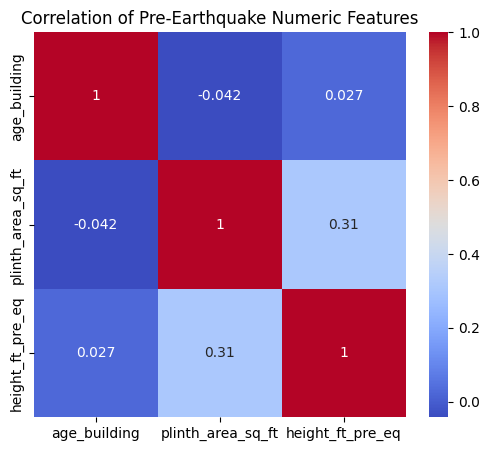

In [6]:
numeric_cols = ["age_building", "plinth_area_sq_ft", "height_ft_pre_eq"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Pre-Earthquake Numeric Features")
plt.savefig("../images/correlation_heatmap.png", dpi=150)
plt.show()


No strong correlations left among the numeric features -- `count_floors_pre_eq` (the
one that was correlated with height) already got dropped back in the SQL notebook.

# **Explore**

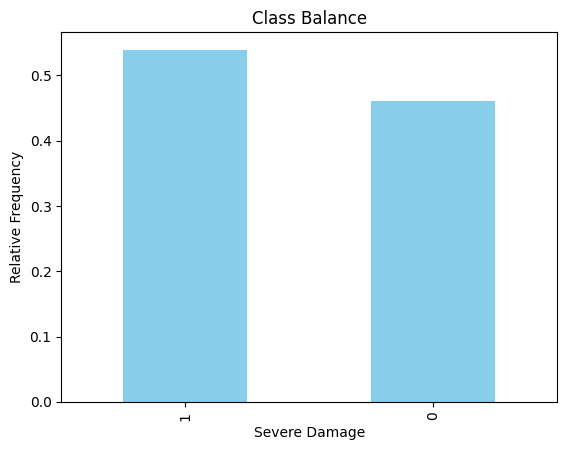

In [7]:
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar", color="skyblue",
    xlabel="Severe Damage", ylabel="Relative Frequency",
    title="Class Balance"
)
plt.savefig("../images/class_balance.png", dpi=150)
plt.show()


Classes aren't too imbalanced -- roughly 60/40 split. Good enough that accuracy is
still a reasonable metric to track, without needing to reach for something like F1 right away.

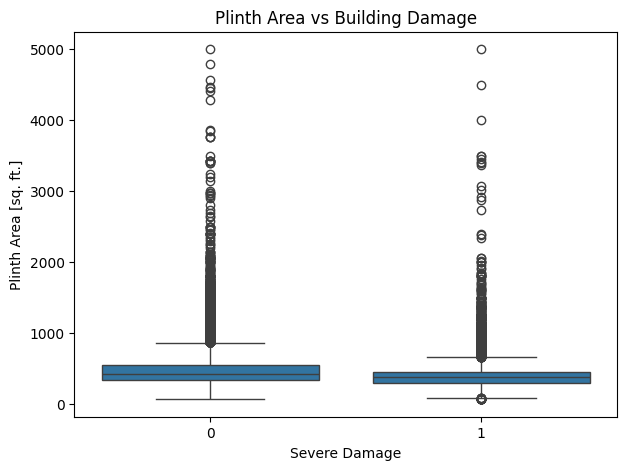

In [8]:
plt.figure(figsize=(7,5))
sns.boxplot(x="severe_damage", y="plinth_area_sq_ft", data=df)
plt.xlabel("Severe Damage")
plt.ylabel("Plinth Area [sq. ft.]")
plt.title("Plinth Area vs Building Damage")
plt.savefig("../images/plinth_area_vs_damage.png", dpi=150)
plt.show()


In [9]:
roof_pivot = pd.pivot_table(
    df, index="roof_type", values="severe_damage", aggfunc="mean"
).sort_values("severe_damage")
roof_pivot

,severe_damage
roof_type,
RCC/RB/RBC,0.037574
Bamboo/Timber-Heavy roof,0.570629
Bamboo/Timber-Light roof,0.601164


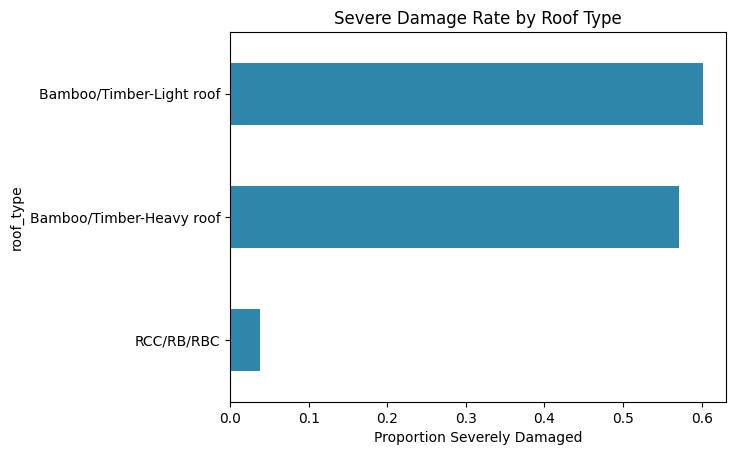

In [10]:
roof_pivot.plot(kind="barh", legend=False, color="#2E86AB")
plt.xlabel("Proportion Severely Damaged")
plt.title("Severe Damage Rate by Roof Type")
plt.savefig("../images/roof_type_damage.png", dpi=150)
plt.show()


Roof type looks like it matters a lot -- buildings with heavier bamboo/timber roofs
show up with very different damage rates than lighter or RCC roofs. Worth watching whether
this shows up again in feature importance once the models are built.

# **Splitting Data into Feature Matrix and target vector**

In [11]:
target = "severe_damage"

y = df[target]
X = df.drop(columns=target)

In [12]:
y

building_id
240101000011    0
240101000021    1
240101000031    1
240101000041    1
240101000051    1
               ..
249009000951    1
249009000961    0
249009000971    1
249009000981    0
249009000991    0
Name: severe_damage, Length: 98019, dtype: int64

In [13]:
X.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration
building_id,,,,,,,,,,
240101000011,40,324,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular
240101000021,30,382,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Attached-1 side,Rectangular
240101000031,13,405,10,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular
240101000041,25,328,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,Rectangular
240101000051,15,405,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular


# **Splitting into Training and Testing set**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (78415, 10)
X_test shape: (19604, 10)


In [15]:
# saving the split so all 3 model notebooks train/evaluate on identical data
X_train.to_csv("../data/X_train.csv")
X_test.to_csv("../data/X_test.csv")
y_train.to_csv("../data/y_train.csv")
y_test.to_csv("../data/y_test.csv")
print("saved")

saved
